##### Author: Tobias Flörchinger, 608227, floercht@hu-berlin.de

# Computational Part of the Master Thesis: <br><br> Predicting Interdependent Diseases in Individuals <br> Using Survey Data and Machine Learning Algorithms <br>

## Table of Contents
0. [Environment](#zero-bullet)
1. [Functions and Data](#first-bullet)
2. [Selection of Target Diseases by Marginal Dependency](#second-bullet)
3. [Explanatory Variable Selection](#third-bullet)
<br> 3.1 Qualitative Assessment of Variables
<br> 3.2 Handling of Data Types
<br> 3.3 Quantitative Variable Selection 
<br> 3.4 Missing Values and Imputation
<br> 3.5 Encoding and Evaluation of Data Processing
4. [Probabilistic Base Algorithms](#fourth-bullet)
<br> 4.1 Optimization of Hyperparameters
<br> 4.2 Evaluation of Base Algorithms
<br> 4.3 A Label-wise Perspective
5. [Multi-label Approaches](#fifth-bullet)
<br> 5.1 Optimization of Approaches
<br> 5.2 Deinition of Approaches
<br> 5.3 Evaluation of Approaches
<br> 5.4 Test for Significance in Improvements

## Environment <a class='anchor' id='zero-bullet'></a>

### NOTE !
In order to reproduce the MA results and ensure the code to work properly, the Anaconda version `2021.11` is required, i.e. `Anaconda3-2021.11-Windows-x86_64.exe` from [here](https://repo.anaconda.com/archive/).
Additionally, the [Microsoft Build Tools für C++](https://visualstudio.microsoft.com/de/visual-cpp-build-tools/) installation "`Desktopentwicklung mit C++`" is required with the default packages.

In [1]:
# Get a list of currently installed packages
packages_installed = !pip list
packages_installed = [x.split()[0] for x in packages_installed] 

# Required packages that are build-in: ['multiprocessing', 'time', 'random', 'os','more-itertools']

# Other required packages (possible already part of anaconda)
packages_required = [ 'pandas', 'numpy', 'matplotlib', 'scipy', 'pyreadstat', 'kneed',
                      'category-encoders', 'scikit-learn', 'scikit-multiflow',
                      'scikit-multilearn', 'xgboost', 'tensorflow' ] 

# Iterate over needed packages and check whether they are installed
for pack in packages_required:
    if pack in packages_installed:
        print('Module is already installed: %s' %pack)
    else:
        print('NOTE: Module %s needs to be installed!' %pack) 

Module is already installed: pandas
Module is already installed: numpy
Module is already installed: matplotlib
Module is already installed: scipy
Module is already installed: pyreadstat
Module is already installed: kneed
Module is already installed: category-encoders
Module is already installed: scikit-learn
Module is already installed: scikit-multiflow
Module is already installed: scikit-multilearn
Module is already installed: xgboost
Module is already installed: tensorflow


In [ ]:
# Installs packages that are neighter build-in nor part of anaconda

!pip install pyreadstat
!pip install kneed
!pip install category-encoders
!pip install scikit-learn
!pip install scikit-multiflow 
!pip install scikit-multilearn
!pip install xgboost
!pip install tensorflow

In [19]:
# Build-in utilities
import os 
import multiprocessing 
import time 
import random as random
import itertools

# Data Managment and Numerical Operations
import pyreadstat
import pandas as pd
import numpy as np
from numpy.random import seed
from sklearn.utils import resample

 # Plots
import matplotlib.pyplot as plt

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from kneed import KneeLocator
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from category_encoders import WOEEncoder

# Evaluation
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, log_loss, average_precision_score
from sklearn import metrics
from scipy.stats import t as t_dist

# Algortihms and Multi -label Approaches
from sklearn.multioutput import MultiOutputClassifier
from skmultiflow.meta import ClassifierChain as ClassifierChain_Meta
from skmultilearn.problem_transform import BinaryRelevance, ClassifierChain, LabelPowerset
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Feedforward Neural Network Structure
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras import activations, losses, initializers, optimizers
from tensorflow.keras.models import Sequential, Model 
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import he_normal
from tensorflow.keras.layers import Input, Dense, Dropout

## 1. Functions and Data <a class='anchor' id='first-bullet'></a>

In [20]:
# Set seed for whole notebook
global_seed = 123

# Identifies CPU cores (NOTE: cores-2 is used for the computations)
cores = multiprocessing.cpu_count()

In [6]:
def share_missings(dat, dat_mis):
    ''' Plots the proportion of missing values in each column of the provided datasets '''
    
    # Idenftify proporation of missing values
    df = pd.DataFrame(dat.isnull().mean(),columns=['Percentage'])
    df['Percentage_mis'] = dat_mis.isnull().mean()
    df = df.sort_values('Percentage', ascending=False)

    # Generate plot
    ind = np.arange(len(df))
    width = 0.35
    fig, ax = plt.subplots(figsize=(14,4))
    rects1 = ax.bar(ind - width/2, df['Percentage'].to_numpy(), width, label='Non-Responses + Caused by Survey')
    rects3 = ax.bar(ind + width/2, df['Percentage_mis'].to_numpy(), width, label='Non-Responses')
    ax.set_ylabel('Proportion of Item Non-Responses')
    ax.set_xlabel('Explanatory Variables')
    ax.set_xticks(ind)
    ax.set_xticklabels(df.index, rotation=90)
    ax.legend();
    plt.show()
    print('There are {} variables.'.format(len(df.index)))

In [7]:
def pred_BR_Base(base, cvn, X_train, y_train):
    ''' Takes Binary Relevance approach and performaces cross-validation with a base algorithm '''
    
    clf = MultiOutputClassifier(base) # Base Algorithm + Binary Relevance
    cv = KFold(n_splits=cvn, shuffle=True, random_state=global_seed) # Cross-validation
    
    # Transform output of Binary Relevance so a dataset
    pred_proba = cross_val_predict(clf, X_train, y_train, cv=cv, method='predict_proba', n_jobs=cores-2)
    pred_proba = [[t[1] for t in l] for l in pred_proba]
    pred_proba = pd.DataFrame(pred_proba, columns=X_train.index, index=y_train.columns)
    return(pred_proba.transpose())

In [8]:
def scale_data(X_train, X_test):
    ''' Scales data with min-max scaler '''
    
    scaler = MinMaxScaler()
    
    # Fit scaler to X_train and transform X_train
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train.select_dtypes(include=['float64','int64'])),
                           columns=X_train.select_dtypes(include=['float64','int64']).columns, index=X_train.index)
    
    # Transform X_test with fitted scaler
    X_test_scaled = pd.DataFrame(scaler.transform(X_test.select_dtypes(include=['float64','int64'])),
                              columns=X_train.select_dtypes(include=['float64','int64']).columns, index=X_test.index )
    
    # Replace data in X_train and X_test
    X_train[X_train.select_dtypes(include=['float64','int64']).columns] = X_train_scaled
    X_test[X_test.select_dtypes(include=['float64','int64']).columns] = X_test_scaled
    
    return X_train, X_test

In [9]:
def brier_multi(targets, probs):
    ''' Calculate average Brier Score '''
    
    return np.mean(np.mean((probs - targets)**2, axis= 0))

In [10]:
def auprc_score(targets, probas):
    ''' Calculate average Area under the Precision-Recall Curve '''
    
    pr_auc_list = []
    for i in targets.columns:
        # Calculate Rates
        precision, recall, _ = precision_recall_curve(targets[i], probas[i])
        # Append rates to list
        pr_auc_list.append( metrics.auc(recall, precision) )
        
    return np.mean(pr_auc_list)

In [11]:
def insample_to_dataset(data):
    ''' Transform insample output for y_train of approaches to a dataset '''
    
    data = [[t[1] for t in l] for l in data]
    data = pd.DataFrame(data, columns=y_train.index, index=y_train.columns)
    
    return data.transpose()

In [12]:
def pred_to_dataset(data, y_test):
    ''' Transform output for y_test of approaches to a dataset '''
    
    data = [[t[1] for t in l] for l in data]
    data = pd.DataFrame(data, columns=y_test.index, index=y_test.columns)
    
    return data.transpose()

In [13]:
def get_metrics(y_test, pred_proba, time):
    ''' Generate and return list of relevant evaluation metrics '''
    
    metrics = []
    metrics.append(log_loss(y_test,pred_proba))
    metrics.append(brier_multi(y_test,pred_proba))
    metrics.append(roc_auc_score(y_test,pred_proba,average='macro'))
    metrics.append(auprc_score(y_test,pred_proba))
    metrics.append(time)
    
    return(metrics)

In [14]:
def get_pred(model, X_train, y_train, X_test, y_test):
    ''' Generate prediction with a model '''
    
    # Fit model and take the time 
    start = time.time()
    model.fit(X_train, y_train)
    t = round((time.time() - start), 2)
    
    # Generate predictions 
    pred_proba = model.predict_proba(X_test)
    pred_proba = pred_to_dataset(pred_proba,y_test)
    
    return(pred_proba, t)

In [15]:
def plot_ROC_AUC(probas, head):
    ''' Plot the ROC_AUC '''
    
    # Adjust figure size
    plt.figure(figsize=(6, 4))   
    roc_auc_list = []
    
    for i in y_train.columns:
        # Calculate Rates
        selectivity, recall, _ = metrics.roc_curve(y_test[i], probas[i])
        # Plot curve
        plt.plot(selectivity, recall, label = i + " (AUC = %0.4f)" % metrics.auc(selectivity, recall) )
     # Random guessing
    plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='black', label='Random guess')
    
    # Plot configuration
    plt.ylabel("True Positive Rate")
    plt.xlabel("False Positive Rate")
    plt.legend(loc="lower right")
    plt.title(head + ' ROC Curves')
    plt.show()

In [16]:
def plot_PR_AUC(probas, head):
    ''' Plot the PR_AUC '''
    
    plt.figure(figsize=(6, 4))
    pr_auc_list = []

    for i in y_train.columns:
        # Calculate Rates
        precision, recall, _ = precision_recall_curve(y_test[i], probas[i])
        # Plot curve
        plt.plot(recall, precision, label = i + " (AUC = %0.4f)" % metrics.auc(recall, precision) )
        pr_auc_list.append( metrics.auc(recall, precision) )
    # Opt. Classifier
    plt.plot([0, 1], [1, 1], linestyle='--', lw=1, color='black', label='Optimal Classifier')
    
    # Plot configuration
    plt.title(head + ' Precision-Recall Curves')
    plt.ylabel("Positive Predictive Value (= Precision)")
    plt.xlabel("True Positive Rate (= Recall)")
    plt.legend(loc="upper right")
    plt.show()

In [17]:
def woe_enc_cat(X_train, X_test):
    ''' Generate the WoE encoding '''
    
    # Gather categorical variables
    df_cat = X_train[list(X_train.select_dtypes(include=[object]).columns)]
    df_cat_test = X_test[list(X_train.select_dtypes(include=[object]).columns)]
    
    encoder = WOEEncoder()

    for i in y.columns:
        encoder.fit(df_cat, y_train[i])
        
        # Transform categorical valiables for each target variable
        df_train = encoder.transform(df_cat).set_axis(df_cat.columns + '_' + i, axis=1, inplace=False)
        df_test = encoder.transform(df_cat_test).set_axis(df_cat.columns + '_' + i, axis=1, inplace=False)
        
        # Add encoding to the data
        X_train = pd.merge(X_train, df_train, how='left', left_index=True, right_index=True)
        X_test = pd.merge(X_test, df_test, how='left', left_index=True, right_index=True)

    # Remove original categorical columns
    X_train = X_train.drop(df_cat.columns, axis=1).copy()
    X_test = X_test.drop(df_cat.columns, axis=1).copy()
    return X_train, X_test

In [18]:
def gridsearch_BRRF(max_depth, max_features, max_samples):
    ''' Gridsearch for Binary Relevance + Random Forest'''
    
    # Initialize validation loss list used for specification identification
    val_loss = []
    
    # Initialize hyperparameter lists
    depth_list = []
    features_list = []
    samples_list = []
    
    # Initialize evaluation metric lists 
    brier = []
    roc_auc = []
    auprc = []

    counter = 0
    for k in max_depth:
        for i in max_features:
            for j in max_samples:
                if (counter > 0 and counter % 25 == 0):
                    print( 'Iteration {} of %s'.format(counter) % (len(max_depth)*len(max_features)*len(max_samples)) )
                counter += 1

                # Cross-validation
                pred = pred_BR_Base(RandomForestClassifier(max_depth = k, max_features = i, max_samples = j,
                                                           criterion = 'entropy', random_state=global_seed),
                                    5, X_train, y_train)
                
                # Assessment of cross-validated predictions with binary cross entropy and append score to list
                val_loss.append(log_loss(y_train, pred))
                
                # Cross-validated evaluation metrics
                brier.append(round(brier_multi(y_train,pred),4))
                roc_auc.append(round(roc_auc_score(y_train,pred,average='macro'),4))
                auprc.append(round(auprc_score(y_train,pred),4))
                
                # Append hyperparamter specifications to list
                depth_list.append(k)
                features_list.append(i)
                samples_list.append(j)
    print()
    # Search lists to identify best specification by minimal validation loss
    print('The best max_depth is {}.'.format(round(depth_list[np.argmin(val_loss)],4)))
    print('The best max_features is {}.'.format(round(features_list[np.argmin(val_loss)],4)))
    print('The best max_samples is {}.'.format(round(samples_list[np.argmin(val_loss)],4)))
    print()
    print('CV LogLoss: {}'.format(round(val_loss[np.argmin(val_loss)],5)))
    print('CV Brier-Multi: {}'.format(round(brier[np.argmin(val_loss)],5)))
    print('CV AUROC: {}'.format(round(roc_auc[np.argmin(val_loss)],5)))
    print('CV AUPRC: {}'.format(round(auprc[np.argmin(val_loss)],5)))
    print()

In [17]:
def gridsearch_mlrf(max_depth, max_features, max_samples):
    ''' Gridsearch for Multi-label Random Forest'''
    
    # Initialize validation loss list used for specification identification
    val_loss = []
    
    # Initialize hyperparameter lists
    depth_list = []
    features_list = []
    samples_list = []

    counter = 0
    for k in max_depth:
        for i in max_features:
            for j in max_samples:
                if (counter > 0 and counter % 25 == 0):
                    print( 'Iteration {} of %s'.format(counter) % (len(max_depth)*len(max_features)*len(max_samples)) )
                counter += 1

                # Cross-validation with multi-label random forest
                clf = RandomForestClassifier(max_depth = k, max_features = i, max_samples = j, random_state=global_seed)
                cv = KFold(n_splits=5, shuffle=True, random_state=global_seed)
                
                # Generate predictions and format
                pred_proba = cross_val_predict(clf, X_train, y_train, cv=cv, method='predict_proba', n_jobs=cores-2)
                pred_proba = [[t[1] for t in l] for l in pred_proba]
                pred_proba = pd.DataFrame(pred_proba, columns=X_train.index, index=y_train.columns)
                pred_proba = pred_proba.transpose()

                # Assessment of cross-validated predictions with binary cross entropy and append score to list
                val_loss.append(log_loss(y_train,pred_proba))
                
                # Append hyperparamter specifications to list
                depth_list.append(k)
                features_list.append(i)
                samples_list.append(j)
    print()
    # Search lists to identify best specification by minimal validation loss
    print('The optimal max_depth is {}.'.format(round(depth_list[np.argmin(val_loss)],4)))
    print('The optimal max_features is {}.'.format(round(features_list[np.argmin(val_loss)],4)))
    print('The optimal max_samples is {}.'.format(round(samples_list[np.argmin(val_loss)],4)))

In [18]:
def gridsearch_BRGB(depth, eta = [0.3], n_est = [100]):
    ''' Gridsearch for Binary Relevance + Gradient Boosted trees '''
    
    # Initialize validation loss list used for specification identification
    val_loss = []
    
    # Initialize hyperparameter lists
    n_est_list = []
    eta_list = []
    depth_list = []
    
    # Initialize evaluation metric lists 
    brier = []
    roc_auc = []
    auprc = []

    counter = 0
    for k in depth:
        for i in n_est:
            for j in eta:
                if (counter > 0 and counter % 25 == 0):
                    print( 'Iteration {} of %s'.format(counter) % (len(depth)*len(eta)*len(n_est)) )
                counter += 1

                # Cross-validation
                pred = pred_BR_Base(xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',use_label_encoder=False,
                                                      max_depth = k, n_estimators=i, learning_rate=j), 5, X_train, y_train)
                
                ## Assessment of cross-validated predictions with binary cross entropy and append score to list
                val_loss.append(log_loss(y_train, pred))
                
                # Cross-validated evaluation metrics
                brier.append(round(brier_multi(y_train,pred),4))
                roc_auc.append(round(roc_auc_score(y_train,pred,average='macro'),4))
                auprc.append(round(auprc_score(y_train,pred),4))
                
                # Append hyperparamter specifications to list
                n_est_list.append(i)
                eta_list.append(j)
                depth_list.append(k)
    print()      
    # Search lists to identify best specification by minimal validation loss
    print('The best tree depth is {}.'.format(round(depth_list[np.argmin(val_loss)],4)))
    print('The best learning rate is {}.'.format(round(eta_list[np.argmin(val_loss)],4)))
    print('The best number of n_estimators is {}.'.format(round(n_est_list[np.argmin(val_loss)],4)))
    print()  
    print('CV LogLoss: {}'.format(round(val_loss[np.argmin(val_loss)],5)))
    print('CV Brier-Multi: {}'.format(round(brier[np.argmin(val_loss)],5)))
    print('CV AUROC: {}'.format(round(roc_auc[np.argmin(val_loss)],5)))
    print('CV AUPRC: {}'.format(round(auprc[np.argmin(val_loss)],5)))
    print()

In [19]:
def gridsearch_BRMLP(layer, rate=[0.001]):
    ''' Gridsearch for Binary Relevance + Multi layer perceptron'''
    
    # Initialize validation loss list used for specification identification
    val_loss = []
    
    # Initialize hyperparameter lists
    layer_list = []
    rate_list = []
    
    # Initialize evaluation metric lists 
    brier = []
    roc_auc = []
    auprc = []

    counter = 0
    for k in layer:
        for i in rate:
            if (counter > 0 and counter % 25 == 0):
                print( 'Iteration {} of %s'.format(counter) % (len(layer)*len(rate)) ) 
            counter += 1

            # Cross-validation
            pred = pred_BR_Base(MLPClassifier(activation='tanh',max_iter=250, hidden_layer_sizes=k, learning_rate_init=i,
                                              early_stopping=True, validation_fraction=0.05, random_state=global_seed),
                                5, X_train, y_train)
            
            # Assessment of cross-validated predictions and append score to list
            val_loss.append(log_loss(y_train, pred))
            
            # Cross-validated evaluation metrics
            brier.append(round(brier_multi(y_train,pred),4))
            roc_auc.append(round(roc_auc_score(y_train,pred,average='macro'),4))
            auprc.append(round(auprc_score(y_train,pred),4))
            
            # Append hyperparamter specifications to list
            layer_list.append(k)
            rate_list.append(i)

    print()
    # Search lists to identify best specification by minimal validation loss
    print('The best number of hidden layers is {}.'.format(round(layer_list[np.argmin(val_loss)],4)))
    print('The best learning rate is {}.'.format(round(rate_list[np.argmin(val_loss)],4)))
    print()
    print('CV LogLoss: {}'.format(round(val_loss[np.argmin(val_loss)],5)))
    print('CV Brier-Multi: {}'.format(round(brier[np.argmin(val_loss)],5)))
    print('CV AUROC: {}'.format(round(roc_auc[np.argmin(val_loss)],5)))
    print('CV AUPRC: {}'.format(round(auprc[np.argmin(val_loss)],5)))
    print()

In [20]:
# Loads the provided .sav data from the directory of this notebook with(out) missings due to survey structure
geda, _ = pyreadstat.read_sav(os.path.join(os.path.dirname(os.path.realpath('MA_Computations_Python.ipynb')), 'GEDA14.sav'),
                              user_missing=False, apply_value_formats=True)
geda_mis, _ = pyreadstat.read_sav(os.path.join(os.path.dirname(os.path.realpath('MA_Computations_Python.ipynb')), 'GEDA14.sav'),
                                  user_missing=True, apply_value_formats=True)
geda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24016 entries, 0 to 24015
Columns: 269 entries, sex to MIcitizen
dtypes: category(253), float64(16)
memory usage: 8.8 MB


## 2. Selection of Target Diseases by Marginal Dependency  <a class='anchor' id='second-bullet'></a>

In [21]:
# Get all disease valiables
col_dis = list(geda.columns[geda.columns.get_loc('KHhyp12'):geda.columns.get_loc('KHalgi112')+1]) # + ['PKdep12']

# Reduce list to 12 month indicators
col_dis12 = [s for s in col_dis if s not in ['KHhyp12','KHhyp','KHhypmedC','KHlipA','KHlipmedA']]

In [22]:
# Convert entries to 0/1 values
dis = geda[col_dis12].replace({'Nein': 0, 'Ja': 1})

# Get relative frequency of diseases
dis_freq = pd.DataFrame(round(dis.apply(dis.value_counts).loc[1]/len(geda),4))
dis_freq = dis_freq[dis_freq[1] > 0.025].rename(columns={1: 'Rel_Freq'})
dis_freq.transpose()

,KHhyp12pB,KHkhk12,KHhi12,KHdiabB12,KHab12,KHkarz12,KHlip12A,KHcb12,KHdge12,KHra12,KHos12,KHalgi112
Rel_Freq,0.308,0.0378,0.0439,0.0713,0.058,0.0376,0.1989,0.0512,0.1623,0.0383,0.041,0.2794


In [23]:
# Identify proportion of missing values
pd.DataFrame(geda[dis_freq.index].isnull().mean(),columns=['Share Missings']).sort_values('Share Missings').transpose()

,KHhyp12pB,KHlip12A,KHdiabB12,KHalgi112,KHkarz12,KHdge12,KHcb12,KHkhk12,KHab12,KHhi12,KHos12,KHra12
Share Missings,0.00204,0.006662,0.02794,0.028065,0.03277,0.05259,0.054714,0.055921,0.056004,0.057795,0.06962,0.071161


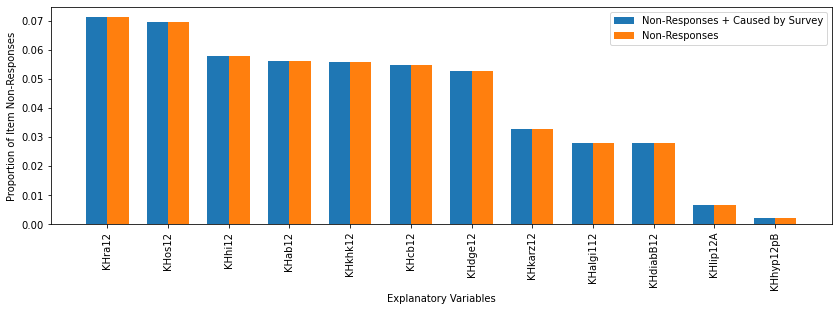

There are 12 variables.


In [24]:
# Plot proportion of missing values
share_missings(geda[dis_freq.index],geda_mis[dis_freq.index])

In [25]:
%%capture

# Take only the complete cases of the 12 disease variables
dis_short = dis[dis_freq.index].dropna()

# Initialize result list
score_matrix = []
sum_score = []

for i in dis_short.columns:
    
    # Calculate chi-squared scores (one vs all)
    chi_scores = chi2(dis_short.drop([i], axis=1).copy(), dis_short[[i]])
    
    # Append scores to result objects
    sum_score.append(np.round(chi_scores[0],3).sum()/(len(dis_short.columns)-1))
    score_matrix.append(chi_scores[0])

In [26]:
# Print results for chi-squared scores
labels = pd.DataFrame(sum_score, index=dis_short.columns, columns=["Avg_chisq"]).sort_values("Avg_chisq", ascending=False)
print(labels)

# Select the five labels with the highest chi-squared score
labels = labels.head(5).index

            Avg_chisq
KHhyp12pB  616.024545
KHhi12     598.676818
KHkhk12    562.458000
KHdge12    554.602182
KHlip12A   354.345636
KHra12     332.699000
KHdiabB12  329.824545
KHos12     272.016364
KHcb12     255.936182
KHab12     196.145636
KHalgi112  118.160909
KHkarz12   102.223727


In [27]:
# Get complete cases of the five selected disease labels 
dis_short = dis[labels].dropna()

# Initialize result list
score_matrix = []

for i in dis_short.columns:
    score_row = []
    for j in dis_short.columns:
        
        # Recalculate the scores for the selected variables only
        chi_scores = chi2(dis_short[[j]], dis_short[[i]])
        score_row.append(np.round(chi_scores[0][0],2))

    score_matrix.append(score_row)

# Print results
pd.DataFrame(score_matrix, index=dis_short.columns, columns=dis_short.columns)

,KHhyp12pB,KHhi12,KHkhk12,KHdge12,KHlip12A
KHhyp12pB,15625.00,1030.15,1075.86,1146.86,1405.49
KHhi12,756.18,21286.00,4136.73,548.60,314.30
KHkhk12,785.24,4113.15,21408.00,369.34,385.77
KHdge12,960.94,626.20,424.00,18648.00,709.88
KHlip12A,1226.38,373.60,461.19,739.25,17907.00


In [28]:
# Complete cases of selected diseases
dis = dis.iloc[geda[labels].dropna().index]

# Target Variables
y = dis[labels]

## 3. Explanatory Variable Selection and Data Pre-Processing <a class='anchor' id='third-bullet'></a>

### 3.1 Qualitative Assessment of Variables

In [29]:
# Direct relation to diseases
col_rel = ['BBmyo12','BBsa12']

# Age subgroups and gender duplicate
col_age_sex = ['sexb'] + list(geda.columns[geda.columns.get_loc('age10B'):geda.columns.get_loc('agegrp12')+1])

# Federal state and region subgroups
col_regions = list(geda.columns[geda.columns.get_loc('bula2'):geda.columns.get_loc('ns3')+1])

# Technical Data
col_stamm = list(geda.columns[geda.columns.get_loc('untm'):geda.columns.get_loc('ppoint')+1]) + ['wQS','wQSpop']
stamm_data = geda[col_stamm]

In [30]:
# Get list of relevant column variables
to_remove = col_dis + col_rel + col_age_sex + col_regions + col_stamm
col_variables = [s for s in geda.columns if s not in to_remove]

In [31]:
# Remove irrelevant columns from the dataset
X = geda[col_variables]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24016 entries, 0 to 24015
Columns: 216 entries, sex to MIcitizen
dtypes: category(205), float64(11)
memory usage: 6.8 MB


### 3.2 Handling of Data Types

In [32]:
%%capture

# Some ordinal scale variables are a mixture of numeric and strings entries. Strings are converted to the numeric equivalent.
X['IAarzt1B12_k'] = X['IAarzt1B12_k'].replace( {'20 oder mehr': 20} )
X['IAfa12_k'] = X['IAfa12_k'].replace( {'20 oder mehr': 20} )
X['IAambC_k'] = X['IAambC_k'].replace( {'10 oder mehr': 10, 'Keine': 0} )

for i in ['KAehispaq2','KAehispaq4','KAehispaq6','KAehispaq8']:
    X[i] = X[i].replace( {'Nie oder seltener als 1 Tag pro Woche': 0} )

X['PAhh_k'] = X['PAhh_k'].replace( {'7 und mehr': 7} )

for i in ['PAhhnbpersk_0_4','PAhhnbpersk_5_13','PAhhnbpersk_14_15','PAhhnbpersk_16_24',
          'PAhhnbpersk_25_64','PAhhnbpersk_65PLUS']:
    X[i] = X[i].replace( {'3 und mehr': 3} )
    
X['SDalo_k'] = X['SDalo_k'].replace( {'6 oder mehr': 6} )

### 3.3  Quantitative Variable Selection 

In [33]:
# Treats all columns as categorical variables and transforms all entires to factors with unique numbers which is 
# needed for the chi-squared statistic
df = pd.merge(y, X, how='left',left_index=True, right_index=True)
df_enc = df.apply(lambda series: pd.Series(LabelEncoder().fit_transform(series[series.notnull()]),
                                                 index=series[series.notnull()].index))
# Initialize result list
chi_2_scores= []

for j in y.columns:
    inter = []
    for i in X.columns:
        
        # Calculate chi-squared score for complete case combination between each label and explanatory variable
        df = df_enc.loc[df_enc[i].dropna().index]
        inter.append(chi2(df[[j]],df[[i]])[0][0])
    chi_2_scores.append(inter)

# Dataset of chi-squared score combinations 
chi_2_scores = pd.DataFrame(chi_2_scores, index = y.columns, columns = X.columns)

# Average chi-squared score per explanatory variable
chi_2_results = pd.DataFrame(np.mean(chi_2_scores), index = X.columns, columns = ['Avg_Chi2'])
chi_2_scores = chi_2_scores.transpose()

In [34]:
# Result for average chi-squared scores
chi_2_results.sort_values('Avg_Chi2', ascending=False)[0:56]

,Avg_Chi2
age5B,2381.288381
SDerwt0a,1669.271477
SDmainstat,1580.238077
AMarztB,1483.534439
GZmehm1,1359.118415
PAhhnbpersk_65PLUS,1314.097859
PAhh_act,1204.103229
BBtreppe,1178.546772
GZmehm2D,1139.442850
IAcholus,1042.693927


The elbow point is at 0.74.


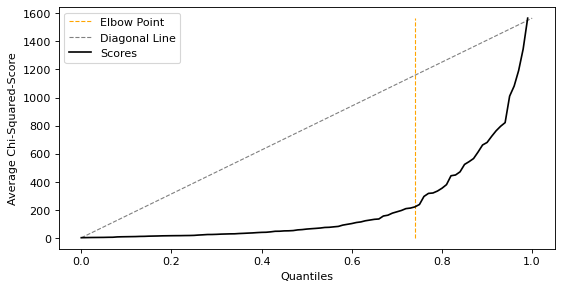

In [35]:
# Initialize result list and quantiles
chisq_quant = []
quant = []

for i in list(np.arange(0, 1, 0.01)):
    
    # Append chi-squared scores for respective quantile
    chisq_quant.append(np.quantile(chi_2_results['Avg_Chi2'],i))
    quant.append(i)

# Identify quantile with maxmium perpitular distance to the diagonal
kneedle = KneeLocator(quant, chisq_quant, S=1.0, curve='convex', direction='increasing')
print('The elbow point is at {}.'.format(kneedle.elbow))

# Plot chi-squared scores by quantiles and the maxmium perpitular distance
plt.figure(figsize=(8, 4), dpi=80)
plt.plot([kneedle.elbow, kneedle.elbow], [0, max(chisq_quant)], linestyle='--', lw=1, color='orange', label='Elbow Point')
plt.plot([0, 1], [0, max(chisq_quant)], linestyle='--', lw=1, color='grey', label='Diagonal Line')
plt.plot(list(np.arange(0, 1, 0.01)), chisq_quant, color='black', label='Scores')
plt.ylabel('Average Chi-Squared-Score')
plt.xlabel('Quantiles')
plt.legend()
plt.show()

In [36]:
# Chi-squared score at the maximum perpitular distance quantile
np.quantile(chi_2_results['Avg_Chi2'], kneedle.elbow)

220.39411832064368

In [37]:
# Selection of variables 
X = X[ chi_2_results[ chi_2_results['Avg_Chi2'] > np.quantile(chi_2_results['Avg_Chi2'], kneedle.elbow) ].index ]
X_mis = geda_mis[X.columns]

###  3.4  Missing Values and Imputation

In [38]:
%%capture
# Change data type of numerical variables 
X.loc[:,X.dtypes == np.float64] = X.loc[:,X.dtypes == np.float64].astype('float32')

In [39]:
# Change dummy variables to 0-1
X = X.replace({'Nein': 0, 'Ja': 1, '0': 0, '1': 1})

# Preserve categorical variables where required (prevent mixture or string and numeric entries)
X[X.select_dtypes(include=object).columns] = X.select_dtypes(include=object).replace({0: 'Nein', 1: 'Ja'})

In [40]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24016 entries, 0 to 24015
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   age5B               24016 non-null  category
 1   GZmehm1             23906 non-null  category
 2   GZmehm3C            23841 non-null  float64 
 3   GZmehm2D            23752 non-null  category
 4   SHseh1              23942 non-null  object  
 5   SHhoer1             23957 non-null  object  
 6   SHhoer5             20764 non-null  category
 7   SHhoer6             20120 non-null  category
 8   BBdors112           23009 non-null  float64 
 9   BBblas12B           23264 non-null  float64 
 10  BBgehen             23860 non-null  category
 11  BBtreppe            23874 non-null  category
 12  BBbehB              23563 non-null  float64 
 13  LQsf367C            23941 non-null  category
 14  LQsf368C            23706 non-null  category
 15  IAhypus             23905 non-null  

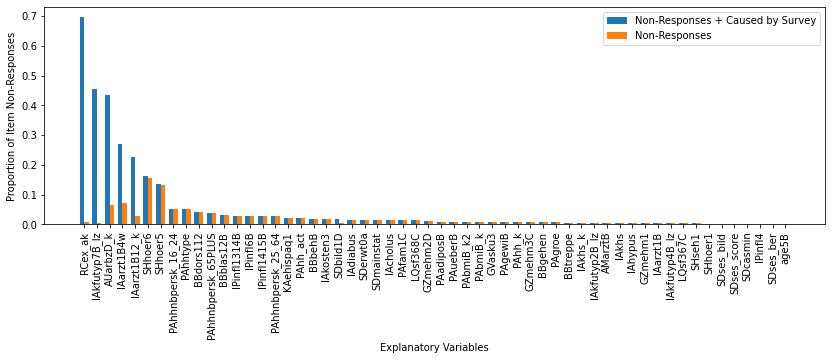

There are 56 variables.


In [41]:
# Proportion of missing values in explanatory variable realizations 
share_missings(X,X_mis)

In [42]:
# Complete cases in explanatory variable realizations 
df = X.iloc[geda[labels].dropna().index]
print('The share of complete cases is {}.'.format(round(len(df.dropna(axis = 0, how = 'any')) / len(df), 4))) 

The share of complete cases is 0.0483.


In [43]:
# Remove explanatory variables with more than 20% missing values in the realizations
df = X.isna().sum()/len(X) 
X = X[[s for s in X.columns if s not in list(df[df > 0.2].index)]]
X_mis = geda_mis[X.columns]

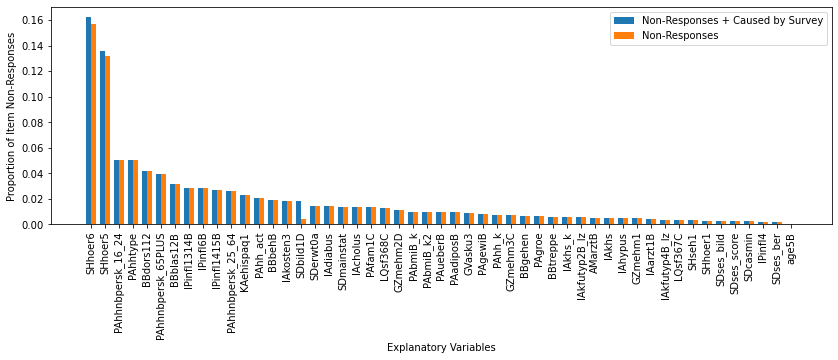

There are 51 variables.


In [44]:
# Proportion of missing values in the remaining explanatory variable realizations 
share_missings(X,X_mis)

In [4]:
# Complete cases in remaining explanatory variable realizations 
df = X.iloc[geda[labels].dropna().index]
print('The share of complete cases is {}.'.format(round(len(df.dropna(axis = 0, how = 'any')) / len(df), 4)))

# Save incomplete data matrix to the directory of this notebook and export to a .csv file 
X_incomplete = X
X.to_csv('X.csv', encoding='iso-8859-1')

NameError: name 'X' is not defined

### NOTE !
The imputation of the missing data is conducted using:
- R in the version `4.1.2` available [here](https://cran.r-project.org/bin/windows/base/old/) 
- RStudio version `2021.9.2.382` available [here](https://www.rstudio.com/products/rstudio/older-versions/#2021092)

With that, the MA_Imputation.R file can be used at the same directory as this notebook to read the just saved .csv file. It is then imputed and exported to the directory of the MA_Imputation.R file as 'X_imp.csv'.

In [3]:
# Read the .csv file of the imputed data from the directory of this notebook
X_imp_mice = pd.read_csv("X_imp.csv", encoding='iso-8859-1')

# Drop auxiliry column generated by imputation
X = X_imp_mice.drop(['Unnamed: 0'], axis=1).copy()
X.info()

# Reduce input matrix to complete cases of target varibles realizations
X = X.iloc[geda[labels].dropna().index]

FileNotFoundError: [Errno 2] No such file or directory: 'X_imp.csv'

### 3.5 Encoding and Evaluation of Data Processing

In [47]:
# Category varibales with numerous category levels
for i in X.select_dtypes(include=['object']).columns:
    if len(X[i].value_counts()) > 10:
        print(i)

age5B
IAkhs_k
SDerwt0a


In [48]:
# Define simple imuter with the most frequent observed value
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

# Fit imputer to data
fit = imp.fit(X_incomplete)

# Transform data for benchmarking
X_imp_spl = pd.DataFrame(fit.transform(X_incomplete),columns = X_incomplete.columns)
X_imp_spl = X_imp_spl.iloc[geda[labels].dropna().index]

In [49]:
# Evaluation metrics of interest
metrics_names = ['LogLoss','Avg BS',"Avg AUROC","Avg AUPRC","Time"]

# Scenarios
scenario_names = ['SI. + One-Hot', 'MI + One-Hot', 'MI + WoE', 'MI + WoE + Scaling']

# Initialize result list
results_scenarios = []

In [50]:
# Unregularized Logistic Regression
LR_base = LogisticRegression(solver='liblinear', random_state=global_seed)

# Simple holdout strategy by one random 70/30 train-test split for simple imputed and CART imputed data
X_train_spl, X_test_spl, y_train, y_test = train_test_split(X_imp_spl, y, test_size=0.3, random_state=global_seed)
X_train, X_test, _ , _ = train_test_split(X, y, test_size=0.3, random_state=global_seed)

#### Scenario 1: Simple Imputation + One-Hot Encoding 

In [51]:
%%capture

# Transform categories in the simple imputed data matrix by one-hot encoding
df_cat = X_imp_spl[X_imp_spl.select_dtypes(include=object).columns]
for i in df_cat.columns:
    X_imp_spl = pd.merge(X_imp_spl, pd.get_dummies(df_cat[i], drop_first=False, dtype=np.uint8),
                            how='left', left_index=True, right_index=True)
    
# Remove original categorical variables
X_imp_spl = X_imp_spl.drop(df_cat.columns, axis=1).copy()

In [52]:
# Split encoded data in train and test according to split
X_train_onehot = X_imp_spl.loc[X_train_spl.index]
X_test_onehot = X_imp_spl.loc[X_test_spl.index]

In [53]:
# Append evaluation results for the predictions of senario 1
proba, t = get_pred(MultiOutputClassifier(LR_base), X_train_onehot, y_train, X_test_onehot, y_test)
results_scenarios.append( get_metrics(y_test, proba, t) )

#### Scenario 2: Multivariate Imputation + One-Hot Encoding  

In [54]:
%%capture

# Transform categories in the data matrix imputed by CART + MICE by one-hot encoding
df_cat = X[X.select_dtypes(include=object).columns]
for i in df_cat.columns:
    X = pd.merge(X, pd.get_dummies(df_cat[i], drop_first=False, dtype=np.uint8), how='left', left_index=True, right_index=True)
    
# Remove original categorical variables
X = X.drop(df_cat.columns, axis=1).copy()

In [55]:
# Split encoded data in train and test according to split
X_train_onehot = X.loc[X_train.index]
X_test_onehot = X.loc[X_test.index]

In [56]:
# Append evaluation results for the predictions of senario 2
proba, t = get_pred(MultiOutputClassifier(LR_base), X_train_onehot, y_train, X_test_onehot, y_test)
results_scenarios.append( get_metrics(y_test, proba, t) )

#### Scenario 3: Multivariate Imputation + WoE Encoding  

In [57]:
# Transform categories in the data matrix imputed by CART + MICE by WoE encoding
X_train, X_test = woe_enc_cat(X_train, X_test)

In [58]:
# Append evaluation results for the predictions of senario 3
proba, t = get_pred(MultiOutputClassifier(LR_base), X_train, y_train, X_test, y_test)
results_scenarios.append( get_metrics(y_test, proba, t) )

#### Scenario 4: Multivariate Imputation + WoE Encoding + Scaling 

In [59]:
# Additional consideration of scaling
X_train, X_test = scale_data(X_train, X_test)

# Append evaluation results for the predictions of senario 4
proba, t = get_pred(MultiOutputClassifier(LR_base), X_train, y_train, X_test, y_test)
results_scenarios.append( get_metrics(y_test, proba, t) )

In [60]:
print('Evaluation of Processing Scenarios:')
pd.DataFrame(results_scenarios, scenario_names, metrics_names)

Evaluation of Processing Scenarios:


,LogLoss,Avg BS,Avg AUROC,Avg AUPRC,Time
SI. + One-Hot,0.931749,0.083430,0.860506,0.430077,2.68
MI + One-Hot,0.908783,0.080617,0.870588,0.451924,1.75
MI + WoE,0.906529,0.080174,0.872026,0.457036,8.75
MI + WoE + Scaling,0.903908,0.080034,0.872607,0.457370,3.83


## 4. Probabilistic Base Algorithms <a class='anchor' id='fourth-bullet'></a>

### 4.1 Optimization of Hyperparameters

In [61]:
%%time

# List of candidates for the strength of the regularization
penalty = list(np.arange(0.5,0.7,0.0025))

# Validation loss to identify specifications with
val_loss = []

# Hyperparameters
brier = []
roc_auc = []
auprc = []

counter = 0
for i in penalty:
    if (counter > 0 and counter % 20 == 0):
        print( 'Iteration {} of %s'.format(counter) % len(penalty) )
    counter += 1
            
    # Generate cross-validated predictions with Binary Relevance + Logistic Regression for each penalty strength
    pred = pred_BR_Base(LogisticRegression(solver='liblinear', penalty='l1', C=i, random_state=global_seed),
                        5, X_train, y_train)
    
    # Assessment of cross-validated predictions with binary cross entropy and save score to list
    val_loss.append(log_loss(y_train, pred))
    
    # Cross-validated evaluation metrics       
    brier.append(brier_multi(y_train, pred))
    roc_auc.append(roc_auc_score(y_train, pred, average='macro'))
    auprc.append(auprc_score(y_train, pred))
print()
print('The optimal penalty is {}.'.format(round(penalty[np.argmin(val_loss)],4)))
print()
print('CV LogLoss: {}'.format(round(val_loss[np.argmin(val_loss)],5)))
print('CV Brier-Multi: {}'.format(round(brier[np.argmin(val_loss)],5)))
print('CV AUROC: {}'.format(round(roc_auc[np.argmin(val_loss)],5)))
print('CV AUPRC: {}'.format(round(auprc[np.argmin(val_loss)],5)))
print()

Iteration 20 of 80
Iteration 40 of 80
Iteration 60 of 80

The optimal penalty is 0.6275.

CV LogLoss: 0.91305
CV Brier-Multi: 0.08128
CV AUROC: 0.87406
CV AUPRC: 0.46296

Wall time: 17min 41s


In [62]:
%%time

# Hyperparameter optimization with Binary Relevance + Random Forest based on the training data 
gridsearch_BRRF(max_depth = list(np.arange(5,10,1)),
                max_features = list(np.arange(0.3,0.45,0.025)),
                max_samples = list(np.arange(0.3,0.45,0.025)) )

Iteration 25 of 245
Iteration 50 of 245
Iteration 75 of 245
Iteration 100 of 245
Iteration 125 of 245
Iteration 150 of 245
Iteration 175 of 245
Iteration 200 of 245
Iteration 225 of 245

The best max_depth is 6.
The best max_features is 0.4.
The best max_samples is 0.35.

CV LogLoss: 0.91788
CV Brier-Multi: 0.082
CV AUROC: 0.8694
CV AUPRC: 0.4536

Wall time: 1h 7min 3s


In [63]:
%%time

# Hyperparameter optimization with Binary Relevance + Gradient Boosted Trees based on the training data 
gridsearch_BRGB(depth = list(np.arange(1,3,1)),
                eta = list(np.arange(0.05,0.15,0.01)),
                n_est = list(np.arange(100,200,10)) )

Iteration 25 of 200
Iteration 50 of 200
Iteration 75 of 200
Iteration 100 of 200
Iteration 125 of 200
Iteration 150 of 200
Iteration 175 of 200

The best tree depth is 2.
The best learning rate is 0.08.
The best number of n_estimators is 150.

CV LogLoss: 0.91248
CV Brier-Multi: 0.0811
CV AUROC: 0.8738
CV AUPRC: 0.4646

Wall time: 48min 57s


In [64]:
%%time

# Hyperparameter optimization with Binary Relevance + Multi-layer Perceptron based on the training data 
gridsearch_BRMLP(layer = list(np.arange(50,150,5)),
                 rate = list(np.arange(0.0001,0.003,0.0002)) )

Iteration 25 of 300
Iteration 50 of 300
Iteration 75 of 300
Iteration 100 of 300
Iteration 125 of 300
Iteration 150 of 300
Iteration 175 of 300
Iteration 200 of 300
Iteration 225 of 300
Iteration 250 of 300
Iteration 275 of 300

The best number of hidden layers is 110.
The best learning rate is 0.0013.

CV LogLoss: 0.93376
CV Brier-Multi: 0.0838
CV AUROC: 0.8572
CV AUPRC: 0.4306

Wall time: 1h 8min 27s


### 4.2 Evaluation of Base Algorithms

In [65]:
# Binary Relevance with relevant Probabilistic Base Algorithms
base_names = ['BR-LR', 'BR-RF', 'BR-GB', 'BR-MLP']

# Initialize result list
results_BR_Base = []

In [66]:
# Identified Regularized Logistic Regression
base_clf_lr = LogisticRegression(solver='liblinear', penalty='l1', C=0.6275, random_state=global_seed)

# Append evaluation results for the predictions of BR-LR
base_clf_lr_proba, t = get_pred(MultiOutputClassifier(base_clf_lr), X_train, y_train, X_test, y_test)
results_BR_Base.append( get_metrics(y_test, base_clf_lr_proba, t) )

In [67]:
# Identified Random Forest
base_clf_rf = RandomForestClassifier(n_estimators=250, max_depth = 6, max_features = 0.4, max_samples = 0.35,
                                     criterion = 'entropy', random_state=global_seed)

# Append evaluation results for the predictions of BR-RF
base_clf_rf_proba, t = get_pred(MultiOutputClassifier(base_clf_rf), X_train, y_train, X_test, y_test)
results_BR_Base.append( get_metrics(y_test, base_clf_rf_proba, t) )

In [68]:
# Identified Gradient Boosted Tree
base_clf_xgb = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False,
                                 max_depth = 2, learning_rate=0.08, n_estimators=150)

# Append evaluation results for the predictions of BR-GB
base_clf_xgb_proba, t = get_pred(MultiOutputClassifier(base_clf_xgb), X_train, y_train, X_test, y_test)
results_BR_Base.append( get_metrics(y_test, base_clf_xgb_proba, t) )

In [69]:
# Identified Multi-layer Perceptron
base_clf_mlp = MLPClassifier(activation='tanh', max_iter=500, hidden_layer_sizes=110 ,learning_rate_init=0.0013,
                             early_stopping=True, validation_fraction=0.05, random_state=global_seed)

# Append evaluation results for the predictions of BR-MLP
base_clf_mlp_proba, t = get_pred(MultiOutputClassifier(base_clf_mlp), X_train, y_train, X_test, y_test)
results_BR_Base.append( get_metrics(y_test, base_clf_mlp_proba, t) )

In [70]:
print('Evaluation of BinaryRelevance:')
pd.DataFrame(results_BR_Base, base_names, metrics_names)

Evaluation of BinaryRelevance:


,LogLoss,Avg BS,Avg AUROC,Avg AUPRC,Time
BR-LR,0.902440,0.079856,0.873591,0.460243,13.81
BR-RF,0.908309,0.081049,0.868318,0.444356,38.28
BR-GB,0.903510,0.080102,0.871980,0.454901,3.85
BR-MLP,0.924570,0.082219,0.855912,0.429019,9.91


### 4.3 A Labelwise Perspective

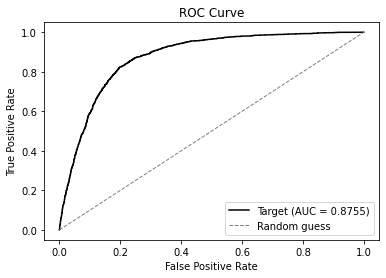

In [71]:
# Example rates for the Receiver Operating Characteristic
selectivity, recall, _ = metrics.roc_curve(y_test['KHhyp12pB'], base_clf_lr_proba.mean(axis=1))

# PLot ROC curve with computed AUC
plt.plot(selectivity, recall, label = 'Target' + " (AUC = %0.4f)" % metrics.auc(selectivity, recall), color='black' )
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='grey', label='Random guess') # Opt. Classifier
    
# Plot configuration
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.legend(loc="lower right")
plt.title('ROC Curve')
plt.show()

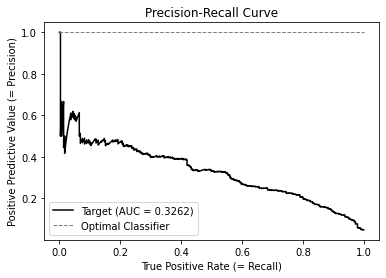

In [72]:
# Example plot for the Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test['KHhi12'], base_clf_lr_proba['KHhi12'])

# PLot Precision-recall curve with computed AUC
plt.plot(recall, precision, label = 'Target' + " (AUC = %0.4f)" % metrics.auc(recall, precision), color='black' )
plt.plot([0, 1], [1, 1], linestyle='--', lw=1, color='grey', label='Optimal Classifier') # Opt. Classifier
    
# Plot configuration
plt.title('Precision-Recall Curve')
plt.ylabel("Positive Predictive Value (= Precision)")
plt.xlabel("True Positive Rate (= Recall)")
plt.legend(loc="lower left")
plt.show()

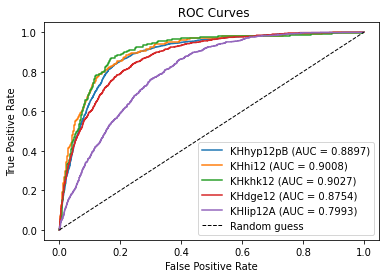

In [73]:
# Label-wise plot of the ROC
plot_ROC_AUC(base_clf_lr_proba,'')

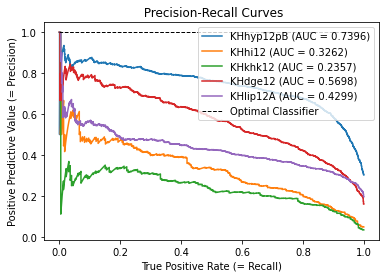

In [74]:
# Label-wise plot of the PRC
plot_PR_AUC(base_clf_lr_proba,'')

## 5. Multi-label Approaches  <a class='anchor' id='fifth-bullet'></a>

In [75]:
# Identified Regularized Logistic Regression
base_clf = LogisticRegression(solver='liblinear', penalty='l1', C=0.6275, random_state=global_seed)

# Identified Random Forest
base_clf_rf = RandomForestClassifier(n_estimators=250, max_depth = 6, max_features = 0.4, max_samples = 0.35,
                                     criterion = 'entropy', random_state=global_seed)

# Identified Gradient Boosted Trees
base_clf_xgb = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False,
                                 max_depth = 2, learning_rate=0.08, n_estimators=150)

# Identified Multi-layer Perceptron
base_clf_mlp = MLPClassifier(activation='tanh', max_iter=500, hidden_layer_sizes=110 ,learning_rate_init=0.0013,
                             early_stopping=True, validation_fraction=0.05, random_state=global_seed)

# Mulit-label approaches considered for comparison
multi_names = ['BR-LR','BR-GB', 'LP', 'CC', 'FCD','MLRF','DNN','EBR','BRS','ECC','HSE','HBE','HBE_opt']

# Initialize result list
results_multi = []

### 5.1 Optimization of  Approaches

#### Chain Order

In [76]:
%%time

# Get all possible chain permutations
perm = list(itertools.permutations([0, 1, 2, 3, 4]))

# Initialize validation loss list
val_loss_perm = []

counter = 0
for i in perm:
    if (counter > 0 and counter % 20 == 0):
        print( 'Iteration {} of %s'.format(counter) % (len(perm)) )
    counter += 1
    # Fit CC with chain order
    chain = ClassifierChain(base_clf, order = i)
    # Generate predictions
    pred_proba = chain.fit(X_train, y_train).predict_proba(X_test).toarray()
    pred_proba = pd.DataFrame(pred_proba, columns=y_train.columns, index=y_test.index)
    # Append validation loss
    val_loss_perm.append(log_loss(y_test.to_numpy(),pred_proba))
print()
print('The optimal chain is {}.'.format(perm[np.argmin(val_loss_perm)]))

Iteration 20 of 120
Iteration 40 of 120
Iteration 60 of 120
Iteration 80 of 120
Iteration 100 of 120

The optimal chain is (0, 1, 2, 3, 4).
Wall time: 26min 32s


#### Multi-label Random Forest

In [77]:
%%time
# Hyperparameter optimization with Binary Relevance + Multi-layer Perceptron based on the training data
gridsearch_mlrf(max_depth = list(np.arange(8, 13, 1)),
                max_features = list(np.arange(0.2, 0.4, 0.025)),
                max_samples = list(np.arange(0.75, 0.95, 0.025)))

Iteration 25 of 320
Iteration 50 of 320
Iteration 75 of 320
Iteration 100 of 320
Iteration 125 of 320
Iteration 150 of 320
Iteration 175 of 320
Iteration 200 of 320
Iteration 225 of 320
Iteration 250 of 320
Iteration 275 of 320
Iteration 300 of 320

The optimal max_depth is 10.
The optimal max_features is 0.275.
The optimal max_samples is 0.925.
Wall time: 55min 25s


#### Multi-label Deep Neural Network

In [78]:
# Row-bind training and test set to use test set selection by early stopping in DNN structure
X_union = pd.concat([X_train, X_test])
y_union = pd.concat([y_train, y_test])

In [79]:
# Set seed 
seed(global_seed)
tf.random.set_seed(global_seed)

# DNN structure
model = Sequential()
model.add(Dense(110, input_dim = len(X_union.columns), kernel_initializer = 'glorot_uniform', activation = 'tanh'))
model.add(Dropout(1/3))
model.add(Dense(110, input_dim = 80, kernel_initializer = 'glorot_uniform', activation = 'tanh'))
model.add(Dense(5, activation='sigmoid'))
model.compile(loss = 'binary_crossentropy', optimizer = optimizers.SGD(learning_rate = 0.05))
model.summary()

# Parameter
epochs = 200
split = 0.3

# Compile and fit the model with early stopping
callbacks = [EarlyStopping(monitor='val_loss', patience = 10, min_delta = 0.00001, restore_best_weights = True)]
story = model.fit(X_union, y_union, epochs = epochs, verbose = 1, validation_split = split, callbacks = callbacks)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 110)               19360     
                                                                 
 dropout (Dropout)           (None, 110)               0         
                                                                 
 dense_1 (Dense)             (None, 110)               12210     
                                                                 
 dense_2 (Dense)             (None, 5)                 555       
                                                                 
Total params: 32,125
Trainable params: 32,125
Non-trainable params: 0
_________________________________________________________________
Epoch 1/200
486/486 [==============================] - 1s 2ms/step - loss: 0.3342 - val_loss: 0.2927
Epoch 2/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2920 -

486/486 [==============================] - 1s 1ms/step - loss: 0.2605 - val_loss: 0.2593
Epoch 73/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2606 - val_loss: 0.2594
Epoch 74/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2605 - val_loss: 0.2594
Epoch 75/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2600 - val_loss: 0.2599
Epoch 76/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2594 - val_loss: 0.2592
Epoch 77/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2601 - val_loss: 0.2709
Epoch 78/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2600 - val_loss: 0.2616
Epoch 79/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2599 - val_loss: 0.2609
Epoch 80/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2600 - val_loss: 0.2600
Epoch 81/200
486/486 [==============================] - 1s 1ms/step - loss: 0.2598 - val_loss: 

### 5.2 Definition of Approaches

#### Binary Relevance Baseline

In [80]:
def BRLR(base_clf, X_train, y_train, X_test, y_test):
    ''' Binary Relevance with the identified specification of Regularized Logistic Regression '''
    
    # Fit and generate predictions
    base_clf_proba, t = get_pred(MultiOutputClassifier(base_clf), X_train, y_train, X_test, y_test)
    
    return get_metrics(y_test, base_clf_proba, t), base_clf_proba

In [81]:
def BRGB(X_train, y_train, X_test, y_test):
    ''' Binary Relevance with the identified specification of Gradient Boosting '''
    
    # Fit and generate predictions
    base_clf_xgb = xgb.XGBClassifier(objective = 'binary:logistic', eval_metric = 'logloss', use_label_encoder = False,
                                     max_depth = 2, learning_rate = 0.08, n_estimators = 170)
    base_clf_xgb_proba, t = get_pred(MultiOutputClassifier(base_clf_xgb), X_train, y_train, X_test, y_test)
    
    return get_metrics(y_test, base_clf_xgb_proba, t), base_clf_xgb_proba

#### Label Powerset

In [82]:
def LP(X_train, y_train, X_test, y_test):
    ''' Label Powerset with Multinomial Regression '''
    
    # Fit LP
    lp = LabelPowerset(LogisticRegression(max_iter = 100, solver = 'saga', multi_class = 'multinomial'))
    start = time.time()
    model = lp.fit(X_train, y_train)
    t = round((time.time() - start), 2)
    
    # Generate predictions
    pred_proba_lp = pd.DataFrame(model.predict_proba(X_test).toarray(), columns = y_train.columns, index = y_test.index)
    
    return get_metrics(y_test, pred_proba_lp, t)


#### Classifier Chains

In [83]:
def CC(X_train, y_train, X_test, y_test):
    ''' Classifier Chain with optimal chain order '''
    
    # Fit CC
    chain = ClassifierChain_Meta(base_clf, order = (0, 1, 2, 3, 4))
    start = time.time()
    model = chain.fit(X_train.to_numpy(), y_train.to_numpy())
    t = round((time.time() - start), 2)
    
    # Generate predictions
    pred_proba_cc = pd.DataFrame(model.predict_proba(X_test), columns = y_train.columns, index = y_test.index)
    
    return get_metrics(y_test, pred_proba_cc, t)


#### Fully Conditional Dependecy

In [84]:
def fcs(base_clf, iteration, X, X_train, y_train, X_test, y_test):
    ''' Computations underlying Fully Conditions Dependency '''
    
    # Training data transformantion of auxiliary labels via cross-validation
    cv = KFold(n_splits = 5, shuffle = True, random_state = global_seed)
    pred_insample = cross_val_predict(MultiOutputClassifier(base_clf), X_train, y_train, cv = cv,
                                      method = 'predict_proba', n_jobs = cores-2)
    pred_insample = [[t[1] for t in l] for l in pred_insample]
    pred_insample = pd.DataFrame(pred_insample,columns = y_train.index, index = y_test.columns)
    pred_insample = pred_insample.transpose()
    data_cond = pd.merge(X, pred_insample, how = 'left', left_index = True, right_index = True)
    
    # Initial prediction with BR-LR
    pred_proba = MultiOutputClassifier(base_clf).fit(X_train, y_train).predict_proba(X_test)
    pred_proba = [[t[1] for t in l] for l in pred_proba]
    pred_proba = pd.DataFrame(pred_proba, columns = y_test.index, index = y_test.columns)
    pred_proba = pred_proba.transpose()

    order = [0, 1, 2, 3, 4]
    for j in range(1,iteration):
        for i in order:
            # Fill predicted values for the transformed auxiliary labels (except the one that has to be updated)
            data_cond.loc[y_test.index, pred_proba.iloc[:,[k for k in order if k not in [i]]].columns] = pred_proba.iloc[:,[k for k in order if k not in [i]]]
            # Define interim training and test data
            X_test_int = data_cond.drop(pred_proba.iloc[:, [i]].columns, axis=1).loc[y_test.index]
            X_train_int = data_cond.drop(pred_proba.iloc[:, [i]].columns, axis=1).loc[y_train.index]
            # Define binary target for fitting
            y_train_int = y_train[pred_proba.iloc[:, [i]].columns].loc[y_train.index]
            # Make predition for the current target
            pred = base_clf.fit(X_train_int, y_train_int.values.ravel()).predict_proba(X_test_int)
            pred = [t[1] for t in pred]
            pred = pd.DataFrame(pred, columns=pred_proba.iloc[:, [i]].columns, index=pred_proba.index)
            # Update the predictions of for the current target
            pred_proba[pred_proba.iloc[:, [i]].columns] = pred
            
    return(pred_proba)

In [85]:
def FCD(X_train, y_train, X_test, y_test, iters = 10):
    ''' Fully Conditions Dependency with optimal chain order and 10 iterations '''
    
    # Row-bind training and test set
    X_con = pd.concat([X_train,X_test], axis=0)
    
    # Fit FCD
    start = time.time()
    pred_proba_fs = fcs(base_clf, iters, X_con, X_train, y_train, X_test, y_test)
    t = round((time.time() - start), 2)
    
    return get_metrics(y_test, pred_proba_fs, t), pred_proba_fs 

#### Multi-label Random Forest

In [86]:
def MLRF(X_train, y_train, X_test, y_test):
    ''' Multi-label Random Forest with optimized specification '''
    
    # Fit MLRF
    start = time.time()
    model = RandomForestClassifier(n_estimators = 250, max_depth = 10, max_features = 0.275, max_samples = 0.925,
                                   criterion = 'entropy', random_state = global_seed).fit(X_train, y_train)
    t = round((time.time() - start), 2)
    
    # Generate predictions
    pred_proba_mlrf = pred_to_dataset(model.predict_proba(X_test),y_test)
    
    return get_metrics(y_test, pred_proba_mlrf, t)

#### Deep Neural Network

In [87]:
def DNN(X_train, y_train, X_test, y_test):
    ''' Deep Neural Network with optimized specification '''
    
    # Set seed 
    tf.random.set_seed(global_seed)

    # DNN structure
    model = Sequential()
    model.add(Dense(110, input_dim = len(X_train.columns), kernel_initializer = 'glorot_uniform', activation = 'tanh'))
    model.add(Dropout(1/3))
    model.add(Dense(110, input_dim = 80, kernel_initializer = 'glorot_uniform', activation = 'tanh'))
    model.add(Dense(5, activation = 'sigmoid'))
    model.compile(loss = 'binary_crossentropy', optimizer = optimizers.SGD(learning_rate = 0.05))

    # Compile and fit the model
    start = time.time()
    model.fit(X_train, y_train, epochs = 89, verbose = 0)
    t = round((time.time() - start), 2)
    
    # Generate predictions
    pred_proba_mlmlp = pd.DataFrame(model.predict(X_test), columns = y_test.columns, index = y_test.index)
    
    return get_metrics(y_test, pred_proba_mlmlp, t)

#### Ensemble of Binary Relevance 

In [88]:
def EBR(X_train, y_train, X_test, y_test, iters = 10):
    ''' Ensemble of Binary Relevance with 10 iterations and subset sampling of 67% of datasize '''
    
    # Initialize required number of BR algorithms and subset parameter
    br_set = [BinaryRelevance(base_clf) for i in range(iters)]
    subset = 0.67
    
    # Fit EBR for each algorithm in the list to a random subsample
    start = time.time()
    for i,br in enumerate(br_set):
        br.fit(X_train.sample(frac = subset, random_state = i),
               y_train.sample(frac = subset, random_state = i))
    t = round((time.time() - start), 2)
    
    # Generate predictions and combine them via averaging
    pred_proba_br = np.array([br.predict_proba(X_test).toarray() for br in br_set])
    pred_proba_ebr = pd.DataFrame(pred_proba_br.mean(axis = 0), columns = y_test.columns, index = y_test.index)
    
    return get_metrics(y_test, pred_proba_ebr, t)

#### Binary Relevance Stacking

In [89]:
def brs(base_clf, folds, X_stack_train, X_stack_test, y_train, y_test):
    ''' Computations underlying Binary Relevance Stacking '''
    
    # Training data transformantion of auxiliary labels via cross-validation and for each stack
    cv = KFold(n_splits=folds, shuffle=True, random_state=global_seed)
    pred_insample = cross_val_predict(MultiOutputClassifier(base_clf), X_stack_train, y_train, cv = cv,
                                      method = 'predict_proba', n_jobs = cores-2)
    pred_insample = [[t[1] for t in l] for l in pred_insample]
    pred_insample = pd.DataFrame(pred_insample, columns = X_stack_train.index, index = y_test.columns)
    pred_insample = pred_insample.transpose()
    
    # Prediction with BR-LR
    pred_proba = MultiOutputClassifier(base_clf).fit(X_stack_train, y_train).predict_proba(X_stack_test)
    pred_proba = [[t[1] for t in l] for l in pred_proba]
    pred_proba = pd.DataFrame(pred_proba, columns = y_test.index, index = y_test.columns)
    pred_proba = pred_proba.transpose()
    
    return pred_proba, pred_insample

In [90]:
def BRS(X_train, y_train, X_test, y_test, stack = 10):
    ''' Binary Relevance Stacking with 10 stacks '''
    
    # Initialize stacking with training and test data
    X_stack_train = X_train
    X_stack_test = X_test
    
    # Fit BRS
    start = time.time()
    for i in range(1,stack):
        # Get data transformations and predictions
        pred_proba, pred_insample = brs(base_clf, 5, X_stack_train, X_stack_test, y_train, y_test)
        # Rename axis via stack number
        pred_proba_merge = pred_proba.set_axis(pred_proba.columns + '_' + str(i), axis=1, inplace=False)
        pred_insample = pred_insample.set_axis(pred_proba.columns + '_' + str(i), axis=1, inplace=False)
        # Merge transformations and predictions to training and test data
        X_stack_train = pd.merge(X_stack_train, pred_insample, how='left', left_index=True, right_index=True)
        X_stack_test = pd.merge(X_stack_test, pred_proba_merge, how='left', left_index=True, right_index=True)
    t = round((time.time() - start), 2)
    
    # Infer predictions from final stack
    pred_proba_brs = pred_proba
    
    return(get_metrics(y_test, pred_proba_brs, t))

#### Ensemble Classifier Chains 

In [91]:
def ECC(X_train, y_train, X_test, y_test, iters = 10):
    ''' Ensemble of Classifier Chains with 10 iterations and subset sampling of 67% of datasize '''
    
    # Initialize required number of CC algorithms and set subset parameter
    chains = [ClassifierChain(base_clf) for i in range(iters)]
    subset = 0.67

    # Fit ECC for each algorithm in the list to a random subsample
    start = time.time()
    for i,chain in enumerate(chains):
        chain.fit(X_train.sample(frac = subset, random_state = i),
                  y_train.sample(frac = subset, random_state = i))
    t = round((time.time() - start), 2) 
    
    # Generate predictions and combine them via averaging
    pred_proba_chains = np.array([chain.predict_proba(X_test).toarray() for chain in chains])
    pred_proba_ecc = pd.DataFrame(pred_proba_chains.mean(axis = 0), columns = y_test.columns, index = y_test.index)

    return get_metrics(y_test, pred_proba_ecc, t)

#### Heterogenous Stacking Ensemble

In [92]:
def HSE(X_train, y_train, X_test, y_test):
    ''' Heterogenous Stacking Ensemble with all Probabilistic Base Algorithms in combination with Binary Relevance '''
    
    # List of models with optimized specifications
    estimators = [ ('xgb', base_clf_xgb), ('rf', base_clf_rf),
                   ('lr', base_clf), ('mlp', base_clf_mlp) ]

    # Fit HSE
    start = time.time()
    stack_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
    # Generate predictions
    pred_proba_hs = pred_to_dataset(MultiOutputClassifier(stack_clf).fit(X_train, y_train).predict_proba(X_test),y_test)
    t = round((time.time() - start), 2)
    
    return get_metrics(y_test, pred_proba_hs, t), pred_proba_hs

#### Heterogenous Bagging Ensemble

In [93]:
def HBE(base_clf_proba, base_clf_xgb_proba):
    ''' Heterogenous Bagging Ensemble with BR-LR and BR-GB predictions '''
    
    # Generate predictions
    pred_proba = base_clf_proba + base_clf_xgb_proba 
    pred_proba_HBE = pred_proba.div(2)
    
    return get_metrics(y_test, pred_proba_HBE, 1)

In [94]:
def HBE_opt(base_clf_proba, base_clf_xgb_proba, pred_proba_fs, pred_proba_hs):
    ''' Heterogenous Bagging Ensemble with BR-LR, BR-GB, FCD and HSE predictions '''
    
    # Generate predictions
    pred_proba = base_clf_proba + base_clf_xgb_proba + pred_proba_fs + pred_proba_hs
    pred_proba_HBE_2 = pred_proba.div(4)
    
    return get_metrics(y_test, pred_proba_HBE_2, 1)

### 5.3 Evaluation of Approaches

In [95]:
# Get seeds for the 5x2 cross-validation
random.seed(global_seed)
seeds = random.sample(range(0, 10000), 5)

# Should match [857, 4385, 1428, 6672, 4367]
seeds 

[857, 4385, 1428, 6672, 4367]

In [96]:
%%time
%%capture

# Initialize result list
results_multi = []

# Initialize metric differences for BR-LR to FCD and HBE of the first fold of the first iteration 
p_1_1_FCD = []
p_1_1_HBE = []

# Initialize variance estimate of the differences for BR-LR to FCD and HBE
s_sqr_FCD = [0,0,0]
s_sqr_HBE = [0,0,0]

# Initialize metric list for BR-LR, FCD and HBE
scores_BRLR = []
scores_FCD = []
scores_HBE = []

# Initialize metric differences for BR-LR to FCD and HBE
diff_scores_FCD = []
diff_scores_HBE = []

for idx_s, seed in enumerate(seeds):
    
    # Equal size split of the dataset in two folds for the current seed 
    folds = KFold(n_splits=2, shuffle=True, random_state=seed)
    
    # Initialize interim results for this two folds
    interim_results = []
    # Initialize score difference in BR-LR to FCD for current fold
    p_i_FCD = []
    # Initialize score difference in BR-LR to HBE for current fold
    p_i_HBE = []
    
    for idx_f, (train_idx, test_idx) in enumerate(folds.split(y, y)):
        
        # Split the data according to the folds (each fold is once considered as train and test)
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
        # Encode the data
        X_train, X_test = woe_enc_cat(X_train, X_test)
        # Scale the data
        X_train, X_test = scale_data(X_train, X_test)
        
        # Evaluation of BR-LR
        BRLR_met, base_clf_proba = BRLR(base_clf, X_train, y_train, X_test, y_test)
        interim_results.append(BRLR_met)
        
        # Evaluation of BR-GB
        BRGB_met, base_clf_xgb_proba = BRGB(X_train, y_train, X_test, y_test)
        interim_results.append(BRGB_met)
        
        # Evaluation of LP
        interim_results.append(LP(X_train, y_train, X_test, y_test))
        
        # Evaluation of CC
        interim_results.append(CC(X_train, y_train, X_test, y_test))
        
        # Evaluation of FCD
        FCD_met, pred_proba_fs = FCD(X_train, y_train, X_test, y_test, iters = 10)
        interim_results.append(FCD_met)
        
        # Evaluation of MLRF
        interim_results.append(MLRF(X_train, y_train, X_test, y_test))
        
        # Evaluation of DNN
        interim_results.append(DNN(X_train, y_train, X_test, y_test))
        
        # Evaluation of EBR
        interim_results.append(EBR(X_train, y_train, X_test, y_test, iters = 10))
        
        # Evaluation of BRS
        interim_results.append(BRS(X_train, y_train, X_test, y_test, stack = 5))
        
        # Evaluation of ECC
        interim_results.append(ECC(X_train, y_train, X_test, y_test, iters = 10))
        
        # Evaluation of HSE
        HSE_met, pred_proba_hs = HSE(X_train, y_train, X_test, y_test)
        interim_results.append(HSE_met)
        
        # Evaluation of HBE
        interim_results.append(HBE(base_clf_proba, base_clf_xgb_proba))
        
        # Evaluation of HBE_opt
        HBE_met = HBE_opt(base_clf_proba, base_clf_xgb_proba, pred_proba_fs, pred_proba_hs)
        interim_results.append(HBE_met)
        
        #####################################################################################
        #########   Test for significance in differences for BR-LR to FCD and HBE   #########
        #####################################################################################
        
        # Note! From here on HBE refers to HBE_opt
        
        # Extract relevant metrics
        score_BRLR = BRLR_met[1:4]
        score_FCD = FCD_met[1:4]
        score_HBE = HBE_met[1:4]
        
        # Calculate differences
        score_diff_FCD = [x-y for x, y in zip(score_BRLR, score_FCD)]
        score_diff_HBE = [x-y for x, y in zip(score_BRLR, score_HBE)]
        
        # Keep metrics and differences history for mean and stdev calculation
        scores_BRLR.append(score_BRLR)
        scores_FCD.append(score_FCD)
        scores_HBE.append(score_HBE)
        diff_scores_FCD.append(score_diff_FCD)
        diff_scores_HBE.append(score_diff_HBE)
        
        # Compute metrics difference for current fold  
        p_i_FCD.append(score_diff_FCD)
        p_i_HBE.append(score_diff_HBE)
        
        # Keep the metric differences of the first fold of the first iteration 
        if (idx_s == 0) & (idx_f == 0):
            p_1_1_FCD.append(p_i_FCD[idx_f])
            p_1_1_HBE.append(p_i_HBE[idx_f])
            
    # Compute mean of metrics difference for the current two fold cross-validation
    p_i_bar_FCD = [(x + y) / 2 for x, y in zip(p_i_FCD[0], p_i_FCD[1])]
    p_i_bar_HBE = [(x + y) / 2 for x, y in zip(p_i_HBE[0], p_i_HBE[1])]                         
    # Compute the variance for the current two fold cross-validation
    s_i_sqr_FCD =  [(x - z) ** 2 + (y - z) ** 2 for x, y, z in zip(p_i_FCD[0], p_i_FCD[1], p_i_bar_FCD)]
    s_i_sqr_HBE =  [(x - z) ** 2 + (y - z) ** 2 for x, y, z in zip(p_i_HBE[0], p_i_HBE[1], p_i_bar_HBE)]
    # Add up to the overall variance
    s_sqr_FCD = [x + y for x, y in zip(s_sqr_FCD, s_i_sqr_FCD)]
    s_sqr_HBE = [x + y for x, y in zip(s_sqr_HBE, s_i_sqr_HBE)]    
        
    results_multi.append(interim_results)

Wall time: 56min 46s


In [97]:
# Initialize result list for the aggregate over the 5 iterations of the two fold cross-validation
agg = []

for i in range(len(results_multi)):
    # Initialize interim result list
    inter = []
    # Append average of fold metric results to the aggregation list
    for j in range(len(multi_names)):
        inter.append([(x+y)/2 for x, y in zip(results_multi[i][0:13][j], results_multi[i][13:26][j])])
    agg.append(inter)

# Aggregate the results over the five interations of the two fold cross-validation
results_agg = pd.DataFrame(agg[0]) + pd.DataFrame(agg[1]) + pd.DataFrame(agg[2]) + pd.DataFrame(agg[3]) + pd.DataFrame(agg[4])
pd.DataFrame(np.array(results_agg.div(5)), multi_names, metrics_names)

,LogLoss,Avg BS,Avg AUROC,Avg AUPRC,Time
BR-LR,0.917056,0.081638,0.870191,0.453243,2.809
BR-GB,0.914385,0.081864,0.869562,0.452484,3.634
LP,0.924541,0.082783,0.865982,0.438574,29.896
CC,0.918649,0.081661,0.870095,0.453817,2.805
FCD,0.916084,0.081577,0.870861,0.453946,38.242
MLRF,0.924985,0.083683,0.862132,0.439588,13.911
DNN,0.918906,0.082179,0.869025,0.449013,28.322
EBR,0.916563,0.081629,0.870098,0.454077,14.511
BRS,0.918870,0.081873,0.869118,0.447289,36.595
ECC,0.919751,0.081850,0.869627,0.454155,14.669


### 5.4 Test for Significance in Improvements

In [98]:
# Relevant metric results of BR-LR in the 5x2 cross validation
scores_BRLR

[[0.08148858051891472, 0.8679437158662651, 0.44689096009154594],
 [0.08167352371364293, 0.8722881908021053, 0.4583909626432443],
 [0.08103200198138953, 0.8687860039225536, 0.4487058426057734],
 [0.08229612853397367, 0.8718120618272222, 0.4579291718016204],
 [0.08223070373024002, 0.8672130942463434, 0.44488237125017027],
 [0.08095373889476527, 0.8717379089572264, 0.46132711153698375],
 [0.08120918719597998, 0.8694969380970757, 0.45598783797105097],
 [0.08221501463763961, 0.8706422094183036, 0.4454525023897258],
 [0.08202191661916818, 0.8716252686709431, 0.4615389172508536],
 [0.08126269834622417, 0.8703608585383419, 0.45132132621758847]]

In [99]:
# Relevant metric results of FCD in the 5x2 cross validation
scores_FCD

[[0.08145291017644829, 0.8685500054368024, 0.4475715451915633],
 [0.08162662878938236, 0.8727963678627593, 0.4602972063418057],
 [0.08098221658956128, 0.8696861178872265, 0.4503232448227319],
 [0.08221484589795325, 0.8725260903521569, 0.4586949834887547],
 [0.08220977907055918, 0.8676634213823068, 0.44486424469407415],
 [0.08085789071863247, 0.8727538753562282, 0.4635450078546074],
 [0.0811755431858319, 0.8698699591199238, 0.45388165739370123],
 [0.0821347998460342, 0.8713635034838912, 0.4461726751110474],
 [0.0819694761583551, 0.8727218808484709, 0.46223404559463],
 [0.08114971902043618, 0.8706830422194971, 0.4518741660624935]]

In [100]:
# Relevant metric results of HBE in the 5x2 cross validation
scores_HBE

[[0.08126176776585001, 0.8694386830950742, 0.45037792115728836],
 [0.08129885867003007, 0.8748083032765489, 0.46520310304284207],
 [0.08075349545063663, 0.8704539537213722, 0.45486245616221266],
 [0.08197911135008351, 0.8738972093654624, 0.4633035863893511],
 [0.0819708882640228, 0.8689011123178508, 0.44802047351303836],
 [0.08066299262741083, 0.8741210076319865, 0.4681221499697257],
 [0.08091002953145407, 0.8715043592100946, 0.460755908800843],
 [0.08192814990352286, 0.8721713959394221, 0.4502014489284004],
 [0.08177499637148693, 0.873080895703693, 0.4650388075569305],
 [0.0809623159891239, 0.8721831817339808, 0.4559661871567734]]

In [101]:
# Get averages and standard deviations of the metric results
print("BRLR - Brier (Mean & SD): ", (np.mean([t[0] for t in scores_BRLR]), np.std([t[0] for t in scores_BRLR])))
print("BRLR - AUROC (Mean & SD): ", (np.mean([t[1] for t in scores_BRLR]), np.std([t[1] for t in scores_BRLR])))
print("BRLR - AUPRC (Mean & SD): ", (np.mean([t[2] for t in scores_BRLR]), np.std([t[2] for t in scores_BRLR])))
print()
print("FCD - Brier (Mean & SD): ", (np.mean([t[0] for t in scores_FCD]), np.std([t[0] for t in scores_FCD])))
print("FCD - AUROC (Mean & SD): ", (np.mean([t[1] for t in scores_FCD]), np.std([t[1] for t in scores_FCD])))
print("FCD - AUPRC (Mean & SD): ", (np.mean([t[2] for t in scores_FCD]), np.std([t[2] for t in scores_FCD])))
print()
print("HBE - Brier (Mean & SD): ", (np.mean([t[0] for t in scores_HBE]), np.std([t[0] for t in scores_HBE])))
print("HBE - AUROC (Mean & SD): ", (np.mean([t[1] for t in scores_HBE]), np.std([t[1] for t in scores_HBE])))
print("HBE - AUPRC (Mean & SD): ", (np.mean([t[2] for t in scores_HBE]), np.std([t[2] for t in scores_HBE])))

BRLR - Brier (Mean & SD):  (0.0816383494171938, 0.0004948266612809915)
BRLR - AUROC (Mean & SD):  (0.8701906250346381, 0.001675783090523945)
BRLR - AUPRC (Mean & SD):  (0.4532427003758556, 0.006207978470873397)

FCD - Brier (Mean & SD):  (0.08157738094531944, 0.0005004914452474511)
FCD - AUROC (Mean & SD):  (0.8708614263949264, 0.001782580183011754)
FCD - AUPRC (Mean & SD):  (0.453945877655541, 0.0065167541143976914)

HBE - Brier (Mean & SD):  (0.08135026059236217, 0.0004978184358278277)
HBE - AUROC (Mean & SD):  (0.8720560101995487, 0.0018969424951793298)
HBE - AUPRC (Mean & SD):  (0.4581852042677406, 0.006868424059411592)


In [102]:
# Differences in metrics of BRLR to FCD
diff_scores_FCD

[[3.567034246643175e-05, -0.0006062895705373217, -0.0006805851000173391],
 [4.689492426057651e-05, -0.0005081770606539804, -0.001906243698561405],
 [4.978539182824704e-05, -0.0009001139646729328, -0.0016174022169584967],
 [8.128263602041885e-05, -0.00071402852493474, -0.000765811687134299],
 [2.0924659680843227e-05, -0.0004503271359633798, 1.8126556096120794e-05],
 [9.584817613279839e-05, -0.0010159663990018108, -0.0022178963176236466],
 [3.364401014809004e-05, -0.0003730210228480857, 0.0021061805773497366],
 [8.021479160541523e-05, -0.0007212940655876299, -0.0007201727213216325],
 [5.244046081306908e-05, -0.001096612177527767, -0.0006951283437763855],
 [0.00011297932578799297, -0.0003221836811552192, -0.0005528398449050065]]

In [103]:
# Get averages and standard deviations of the differences
print("BRLR/FCD Diff - Brier (Mean & SD):",(np.mean([t[0] for t in diff_scores_FCD]), np.std([t[0] for t in diff_scores_FCD])))
print("BRLR/FCD Diff - AUROC (Mean & SD):",(np.mean([t[1] for t in diff_scores_FCD]), np.std([t[1] for t in diff_scores_FCD])))
print("BRLR/FCD Diff - AUPRC (Mean & SD):",(np.mean([t[2] for t in diff_scores_FCD]), np.std([t[2] for t in diff_scores_FCD])))
print()

# Compute t value as the first difference divided by the square root of variance estimate
t_bar_FCD =  [x / ((y / 5) ** .5) for x, y in zip(p_1_1_FCD[0], s_sqr_FCD)]
print('T-Statistics of Evaluation Metrics (Avg_Brier, AUROC, AUPRC) : ', t_bar_FCD)
print()

evals = ['Brier', 'AUROC', 'AUPRC']
for idx, t_stat in enumerate(t_bar_FCD):
    dof = 5
    # P-value for 2-sided test
    print('P-Value',evals[idx],': ' ,2*(1 - t_dist.cdf(abs(t_stat), dof))) # 2*(t.cdf(-abs(t_stat), dof))

BRLR/FCD Diff - Brier (Mean & SD): (6.096847187438831e-05, 2.8444314426087764e-05)
BRLR/FCD Diff - AUROC (Mean & SD): (-0.0006708013602882868, 0.0002543385264996176)
BRLR/FCD Diff - AUPRC (Mean & SD): (-0.0007031772796852354, 0.0011409517540514386)

T-Statistics of Evaluation Metrics (Avg_Brier, AUROC, AUPRC) :  [1.00628093403458, -1.8404251256923283, -0.5513791465949588]

P-Value Brier :  0.36046653931582484
P-Value AUROC :  0.1250791995024758
P-Value AUPRC :  0.6051072462965106


In [104]:
# Differences in metrics of BRLR to HBE
diff_scores_HBE

[[0.0002268127530647146, -0.001494967228809152, -0.003486961065742422],
 [0.00037466504361285957, -0.0025201124744436143, -0.006812140399597766],
 [0.0002785065307528978, -0.0016679497988186798, -0.006156613556439261],
 [0.0003170171838901559, -0.002085147538240295, -0.0053744145877306915],
 [0.00025981546621722806, -0.0016880180715074244, -0.003138102262868092],
 [0.00029074626735443865, -0.0023830986747601646, -0.006795038432741929],
 [0.00029915766452591475, -0.0020074211130188813, -0.004768070829792026],
 [0.0002868647341167513, -0.0015291865211184419, -0.0047489465386746366],
 [0.0002469202476812482, -0.0014556270327498178, -0.0034998903060768916],
 [0.00030038235710026784, -0.0018223231956389085, -0.004644860939184925]]

In [105]:
# Get averages and standard deviations of the differences
print("BRLR/HBE Diff - Brier (Mean & SD):",(np.mean([t[0] for t in diff_scores_HBE]), np.std([t[0] for t in diff_scores_HBE])))
print("BRLR/HBE Diff - AUROC (Mean & SD):",(np.mean([t[1] for t in diff_scores_HBE]), np.std([t[1] for t in diff_scores_HBE])))
print("BRLR/HBE Diff - AUPRC (Mean & SD):",(np.mean([t[2] for t in diff_scores_HBE]), np.std([t[2] for t in diff_scores_HBE])))
print()

# Compute t value as the first difference divided by the square root of variance estimate
t_bar_HBE =  [x / ((y / 5) ** .5) for x, y in zip(p_1_1_HBE[0], s_sqr_HBE)]
print('T-Statistics of Evaluation Metrics (Avg_Brier, AUROC, AUPRC) : ', t_bar_HBE)
print()

evals = ['Brier', 'AUROC', 'AUPRC']
for idx, t_stat in enumerate(t_bar_HBE):
    dof = 5
    # P-value for 2-sided test
    print('P-Value',evals[idx],': ' ,2*(1 - t_dist.cdf(abs(t_stat), dof))) # 2*(t.cdf(-abs(t_stat), dof))

BRLR/HBE Diff - Brier (Mean & SD): (0.0002880888248316477, 3.8672101114179724e-05)
BRLR/HBE Diff - AUROC (Mean & SD): (-0.001865385164910538, 0.0003543444206650567)
BRLR/HBE Diff - AUPRC (Mean & SD): (-0.004942503891884864, 0.00127279695190189)

T-Statistics of Evaluation Metrics (Avg_Brier, AUROC, AUPRC) :  [4.340216633104804, -3.2848187406069194, -2.1479826121008574]

P-Value Brier :  0.0074273837205445226
P-Value AUROC :  0.021838015765062835
P-Value AUPRC :  0.08446019741847532
